# CrowdSimPlus baseline: learning the closed-loop interface

This notebook deliberately excludes JMID, CasADi, Acados, and MPC. A **linear robot** always moves directly toward its goal, while **ORCA humans** react to nearby agents and walls. This gives us the smallest useful closed-loop test of `observation -> robot action -> env.step(...)`.

The baseline is intentionally naive. Collisions or freezing are informative: later, SICNav should improve these outcomes rather than merely produce a plausible-looking path.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

start = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (start, *start.parents) if (path / 'CLAUDE.md').exists())
EXPERIMENT_DIR = PROJECT_ROOT / 'experiments' / 'crowd_navigation'
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from baseline import make_environment, plot_episode, policy_is_available, run_episode, run_suite, summarize

print(f'Project: {PROJECT_ROOT}')
print(f'Python-RVO2 available: {policy_is_available("orca_plus")}')

Project: /Users/tahaismail/Desktop/work/lyu_lab/sicnav-diffusion-reproduction
Python-RVO2 available: True


## Configuration

`linear` is a goal-seeking robot policy with no collision reasoning. `orca_plus` uses the locally compiled RVO2 binding and is the paper repository's usual simulated-human policy. Change `HUMAN_POLICY` to `sfm` to compare against Social Force Model humans.

In [8]:
ROBOT_POLICY = 'linear'
HUMAN_POLICY = 'orca_plus'  # Use 'sfm' for the dependency-light alternative.
SCENARIO = 'hallway'
HUMAN_COUNT = 3
STARTS_MOVING = 10
TEST_CASE = 0

environment_kwargs = dict(
    robot_policy=ROBOT_POLICY,
    human_policy=HUMAN_POLICY,
    scenario=SCENARIO,
    human_count=HUMAN_COUNT,
    starts_moving=STARTS_MOVING,
)

## One episode

CrowdSimPlus uses the older four-value Gym API: `observation, reward, done, info = env.step(action)`. The helper retains every executed robot/human position so we can inspect what produced the final metrics.

In [9]:
env, robot = make_environment(**environment_kwargs)
episode = run_episode(env, robot, test_case=TEST_CASE)
pd.Series(episode.metrics).to_frame('value')

,value
test_case,0
robot_policy,Linear
human_policy,ORCAPlus
scenario,hallway
success,True
timeout,False
navigation_time_s,2.0
steps,8
collision_steps,1
wall_collision_steps,0


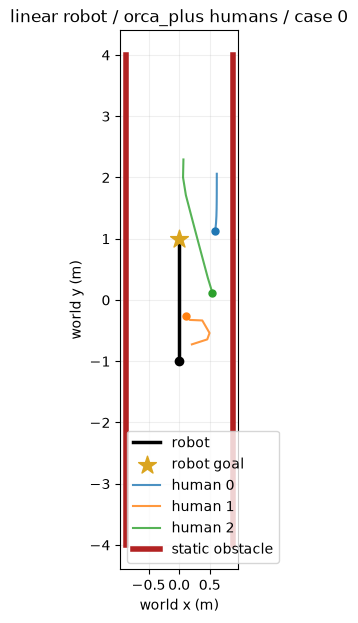

In [10]:
plot_episode(episode, title=f'{ROBOT_POLICY} robot / {HUMAN_POLICY} humans / case {TEST_CASE}')
plt.show()

## Fixed-seed baseline suite

A single episode is useful for debugging but not evaluation. Each integer test case deterministically seeds scene generation. The main navigation metrics are:

- **success/timeout rates:** whether the robot reaches its goal before the time limit.
- **collision rates:** contact with humans or static obstacles; collisions are counted even though this simulator may allow the episode to continue.
- **minimum clearance:** closest edge-to-edge separation; negative means geometric overlap.
- **navigation time and path efficiency:** speed and path straightness (start-to-end displacement divided by executed path length), which expose overly conservative controllers.
- **policy time:** computation per action; this becomes important for JMID and MPC.

In [11]:
NUM_CASES = 25
results, episodes = run_suite(cases=range(NUM_CASES), **environment_kwargs)
summarize(results).to_frame('value')

,value
episodes,25.000000
success_rate,1.000000
timeout_rate,0.000000
episodes_with_collision_rate,0.240000
episodes_with_wall_collision_rate,0.000000
mean_navigation_time_s,2.000000
mean_minimum_clearance_m,0.072812
mean_path_efficiency,1.000000
mean_policy_time_ms,0.002060


In [12]:
display_columns = [
    'test_case', 'success', 'timeout', 'collision_steps', 'wall_collision_steps',
    'danger_steps', 'frozen_steps', 'navigation_time_s',
    'minimum_clearance_m', 'path_efficiency', 'mean_policy_time_ms',
]
results[display_columns]

,test_case,success,timeout,collision_steps,wall_collision_steps,danger_steps,frozen_steps,navigation_time_s,minimum_clearance_m,path_efficiency,mean_policy_time_ms
0,0,True,False,1,0,0,0,2.0,-0.037387,1.0,0.004510
1,1,True,False,0,0,0,0,2.0,0.004190,1.0,0.002656
2,2,True,False,3,0,0,0,2.0,-0.191603,1.0,0.002411
3,3,True,False,0,0,0,0,2.0,0.026997,1.0,0.002261
4,4,True,False,1,0,0,0,2.0,-0.011190,1.0,0.002172
5,5,True,False,2,0,0,0,2.0,-0.039460,1.0,0.004266
6,6,True,False,0,0,0,0,2.0,0.042976,1.0,0.001969
7,7,True,False,0,0,0,0,2.0,0.117311,1.0,0.001875
8,8,True,False,0,0,0,0,2.0,0.055307,1.0,0.001979
9,9,True,False,0,0,0,0,2.0,0.116193,1.0,0.001672


In [13]:
problem_cases = results.loc[
    (~results['success']) | (results['collision_steps'] > 0) | (results['wall_collision_steps'] > 0),
    display_columns,
]
problem_cases

,test_case,success,timeout,collision_steps,wall_collision_steps,danger_steps,frozen_steps,navigation_time_s,minimum_clearance_m,path_efficiency,mean_policy_time_ms
0,0,True,False,1,0,0,0,2.0,-0.037387,1.0,0.004510
2,2,True,False,3,0,0,0,2.0,-0.191603,1.0,0.002411
4,4,True,False,1,0,0,0,2.0,-0.011190,1.0,0.002172
5,5,True,False,2,0,0,0,2.0,-0.039460,1.0,0.004266
10,10,True,False,2,0,0,0,2.0,-0.080855,1.0,0.001672
17,17,True,False,2,0,0,0,2.0,-0.055925,1.0,0.001531


## Inspect a failure

This cell chooses the first unsuccessful/collision episode when one exists. Seeing *how* the linear policy fails is more useful than treating the aggregate collision rate as an abstract score.

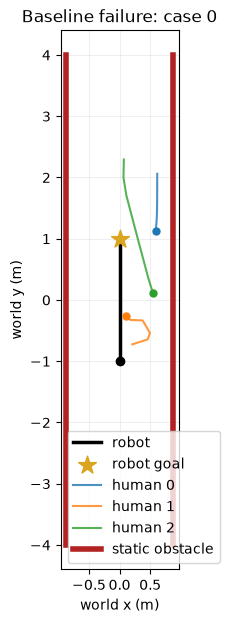

In [14]:
if len(problem_cases):
    failure_case = int(problem_cases.iloc[0]['test_case'])
    plot_episode(episodes[failure_case], title=f'Baseline failure: case {failure_case}')
    plt.show()
else:
    print('No failure occurred in this small suite; increase NUM_CASES or crowd density.')

## Persist results

Keep the per-episode CSV. Later we will run the same case IDs through ORCA, CVMM-MPC, and SICNav-Diffusion so comparisons are paired scene by scene.

In [15]:
OUTPUT_DIR = EXPERIMENT_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH = OUTPUT_DIR / f'{ROBOT_POLICY}_robot_{HUMAN_POLICY}_humans_{SCENARIO}.csv'
results.to_csv(RESULTS_PATH, index=False)
print(f'Wrote {RESULTS_PATH}')

Wrote /Users/tahaismail/Desktop/work/lyu_lab/sicnav-diffusion-reproduction/experiments/crowd_navigation/outputs/linear_robot_orca_plus_humans_hallway.csv
